### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [4]:
from imblearn.over_sampling import RandomOverSampler
import albumentations as A

In [5]:
import tensorflow as tf
from tensorflow import io, image, data
from tensorflow.keras import layers, Model, utils, callbacks, optimizers

### Step 2: Constant

In [6]:
AUTO = data.experimental.AUTOTUNE
IMG_TRAIN_FOLD = './data/traffic_Data/DATA/'
IMG_TEST_FOLD = './data/traffic_Data/TEST/'
IMG_HEIGH = 224
IMG_WIDTH = 224
IMG_CHANNEL = 3
BATCH_SIZE = 32

### Step 3: Feature Engineering

In [7]:
label_encoder = pd.read_csv('./data/traffic_Data/labels.csv')

In [8]:
label_to_num = dict(zip(label_encoder['Name'], label_encoder['ClassId']))
num_to_label = dict(zip(label_encoder['ClassId'], label_encoder['Name']))

### Step 4: Load Data

In [9]:
labels = os.listdir(IMG_TRAIN_FOLD)

In [10]:
df = pd.DataFrame()

In [11]:
for label in labels:
    temp = pd.DataFrame(
        {
            'id': os.listdir(f'{IMG_TRAIN_FOLD}{label}'),
            'label_id': int(label)
        }
    )
    df = pd.concat([df, temp], ignore_index=True)

In [12]:
df['label'] = df['label_id'].map(num_to_label)

In [13]:
df.shape

(4170, 3)

In [14]:
df.sample(5)

,id,label_id,label
7,000_0008.png,0,Speed limit (5km/h)
70,000_1_0011.png,0,Speed limit (5km/h)
3031,049_1_0022_1_j.png,49,Unknown5
1566,028_1_0014.png,28,watch out for cars
2019,003_1_0069.png,3,Speed limit (40km/h)


### Step 5: Exploaring Data

#### Target Distribution

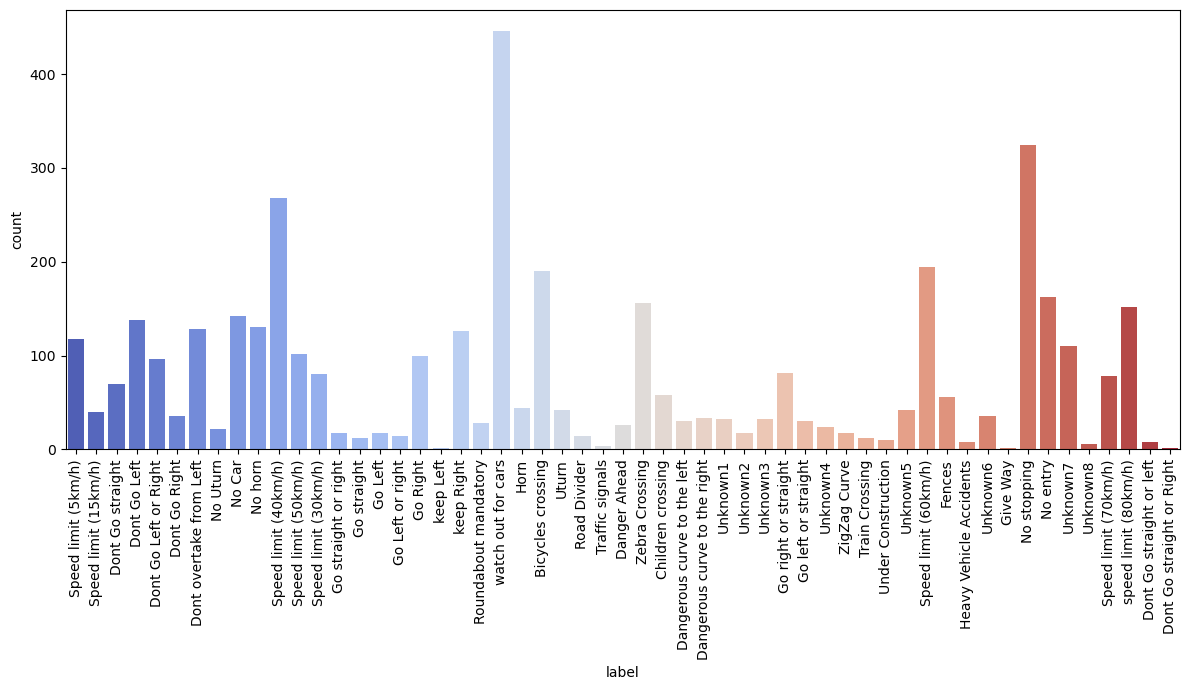

In [15]:
plt.figure(figsize=(12, 7))
sns.countplot(x='label', data=df, palette='coolwarm')
plt.xticks(rotation=90)
plt.tight_layout()

#### Show Data

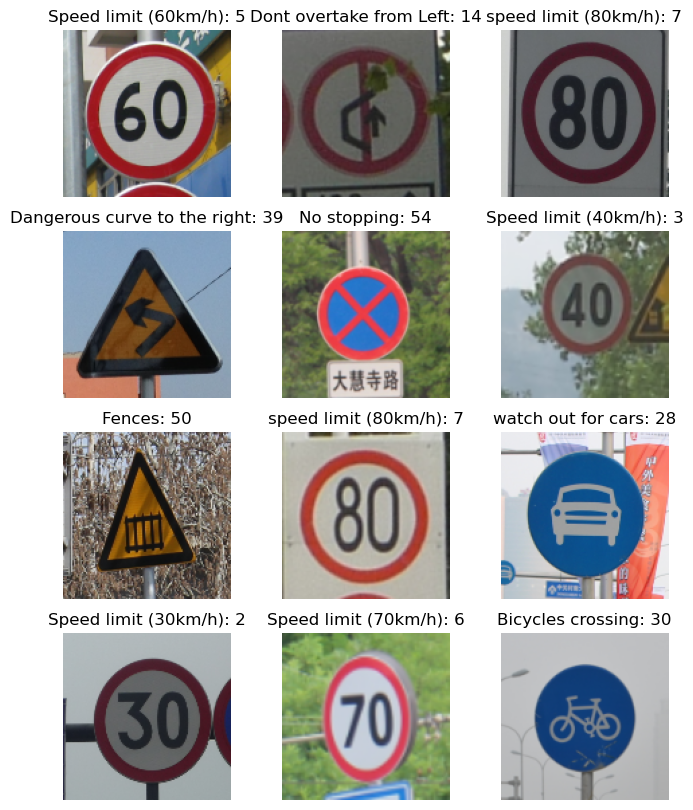

In [16]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    temp = df.sample(1)
    k = np.random.randint(0, len(df))
    img_id = temp['id'].iloc[0]
    label_id = temp['label_id'].iloc[0]
    label = temp['label'].iloc[0]
    img = io.read_file(f'{IMG_TRAIN_FOLD}{label_id}/{img_id}')
    img = image.decode_png(img)
    img = image.resize(img, (125, 125))
    plt.imshow(img/255.0)
    plt.title(f'{label}: {label_id}')
    plt.axis('off')

### Step 6: Preparing Data

#### Split Data

In [17]:
train, value = train_test_split(
    df,
    test_size=0.5,
    random_state=42    
)

In [18]:
test = pd.DataFrame(
    {
        'id': os.listdir(IMG_TEST_FOLD)
    }
)

In [19]:
test['label_id'] = test['id'].str.split('_').str[0].astype('int')

In [20]:
test['label'] = test['label_id'].map(num_to_label)

#### Balance Data

In [21]:
sampler = RandomOverSampler(
    sampling_strategy='all', 
    random_state=42
)

In [22]:
X_train, y_train = sampler.fit_resample(train.drop('label_id', axis=1), train['label_id'])

In [23]:
train = pd.concat([X_train, y_train], axis=1)

#### Albumentation

In [24]:
transform_train = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.CoarseDropout(p=0.2),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2)
    ]
)

In [25]:
transform_test = A.Resize(IMG_HEIGH, IMG_WIDTH)

#### Build Generator

In [26]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['id']
            label_id = row['label_id']
            if is_train:
                try:
                    img = cv2.imread(f'{IMG_TRAIN_FOLD}{label_id}/{img_id}')
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = transform_train(image=img)['image']
                except:
                    print(f'train:{IMG_TRAIN_FOLD}{label_id}/{img_id}')
            else:
                try:
                    img = cv2.imread(f'{IMG_TEST_FOLD}{img_id}')
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = transform_test(image=img)['image']
                except:
                    print(f'test:{IMG_TEST_FOLD}{img_id}')
            img = img.astype('float32') / 255.0
            yield img, label_id
            
    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [27]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, len(label_encoder)))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [28]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [29]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(32, 224, 224, 3) (32, 58)


### Step 7: Model Development

#### Build Model

In [30]:
inputs = layers.Input(shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(128, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
x = layers.MaxPool2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(label_encoder), activation='softmax')(x)

In [31]:
model = Model(inputs, outputs)

In [32]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 128)       │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       3,211,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 58)                  │           7,482 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,674,298 (14.02 MB)

 Trainable params: 3,673,914 (14.01 MB)

 Non-trainable params: 384 (1.50 KB)

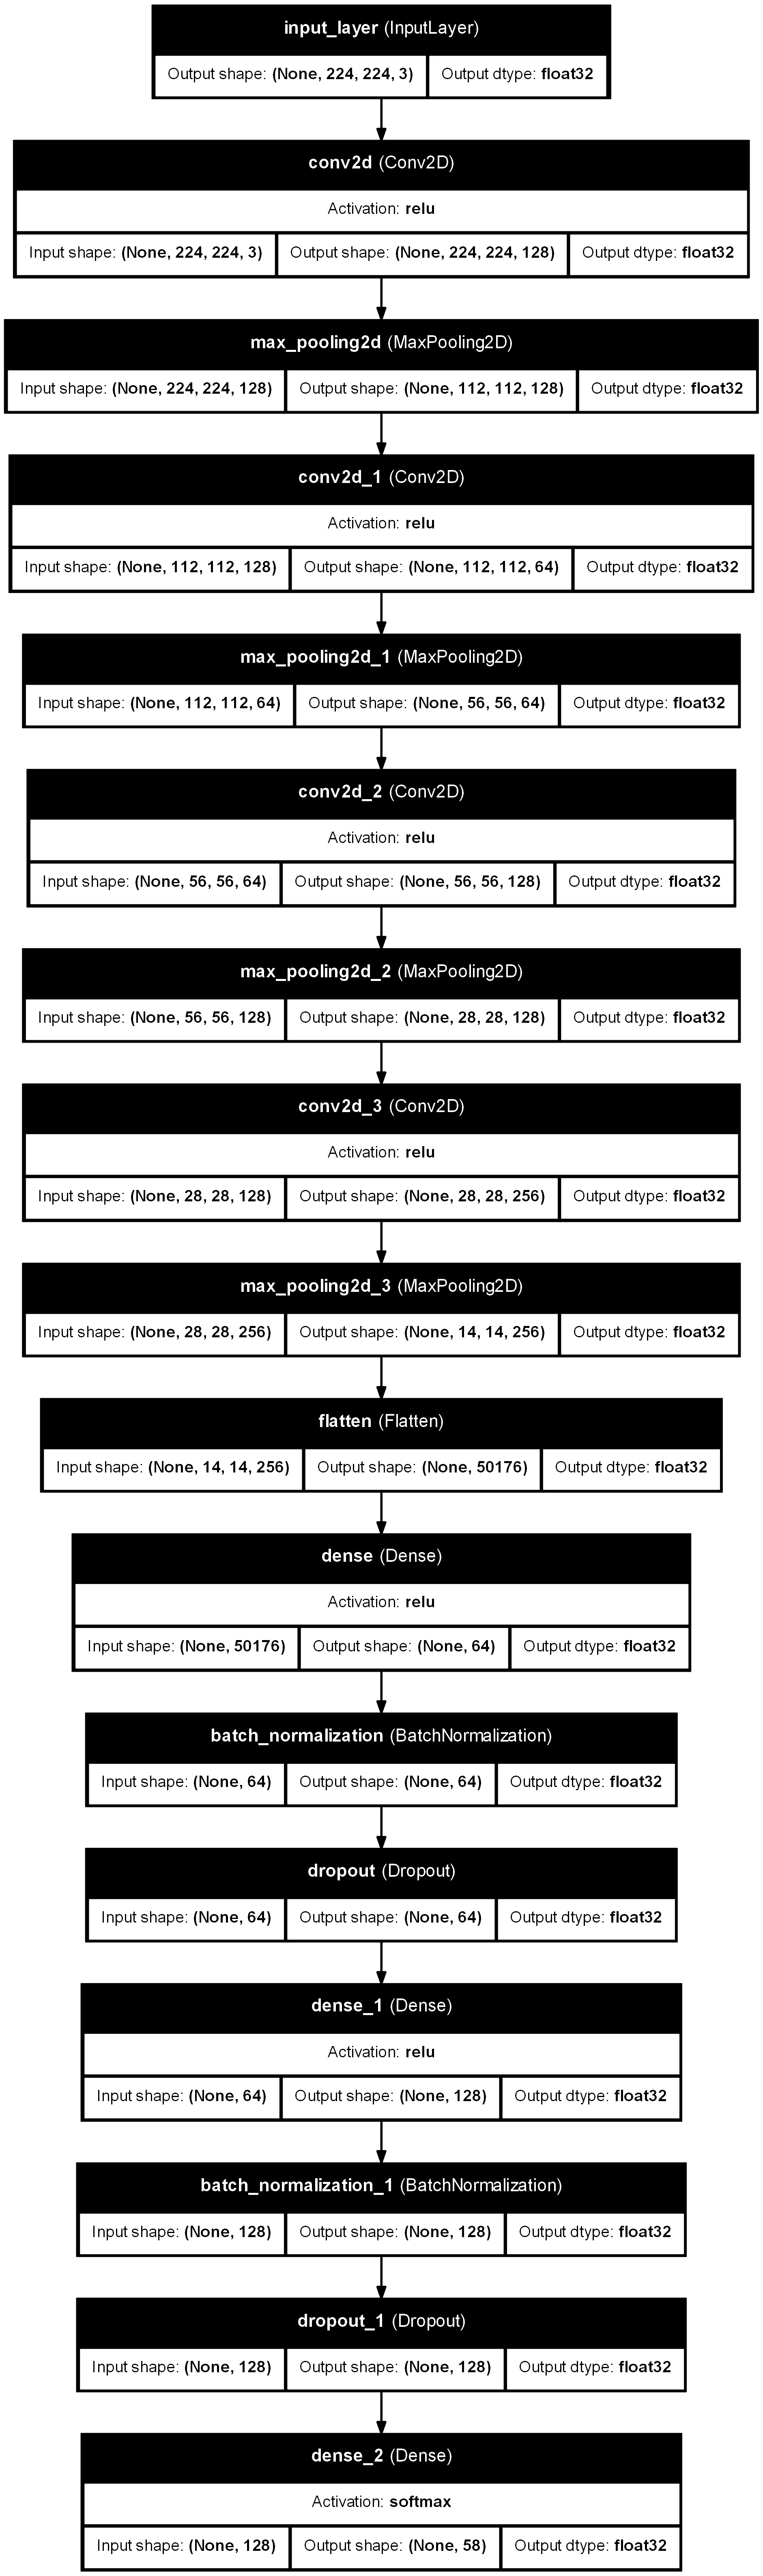

In [33]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    show_layer_activations=True
)

#### Compile Model

In [34]:
optimizer = optimizers.Adam(learning_rate=0.01, clipnorm=1.0)

In [35]:
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### Train Model

In [36]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [37]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [38]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=50,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 370s 989ms/step - accuracy: 0.2311 - loss: 3.1419 - val_accuracy: 0.0182 - val_loss: 7.8233 - learning_rate: 0.0100
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 616s 2s/step - accuracy: 0.2788 - loss: 2.5605 - val_accuracy: 0.0657 - val_loss: 8.2918 - learning_rate: 0.0100
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 759s 2s/step - accuracy: 0.3622 - loss: 2.1965 - val_accuracy: 0.1827 - val_loss: 5.3181 - learning_rate: 0.0100
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 758s 2s/step - accuracy: 0.4206 - loss: 1.9228 - val_accuracy: 0.2216 - val_loss: 4.5041 - learning_rate: 0.0100
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 735s 2s/step - accuracy: 0.4715 - loss: 1.7733 - val_accuracy: 0.2547 - val_loss: 4.3175 - learning_rate: 0.0100
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 741s 2s/step - accuracy: 0.5028 - loss: 1.6443 - val_accuracy: 0.3031 - val_loss: 3.6851 - learning_rate: 0.0100
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.5364 - loss:

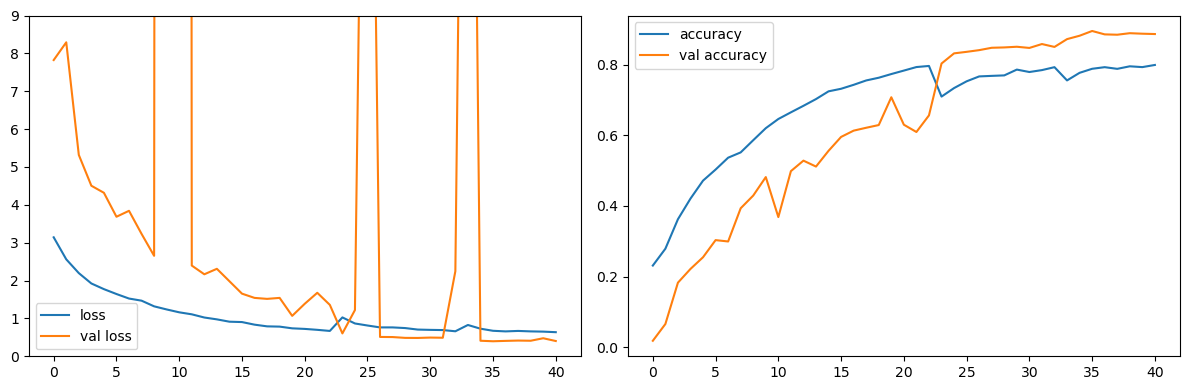

In [44]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylim((0, 9))
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [45]:
loss, accuracy = model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 285ms/step - accuracy: 0.5045 - loss: 2.7302


In [46]:
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 2.73, test accuracy: 0.505


In [47]:
test_pred = model.predict(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step


In [48]:
test['pred_id'] = np.argmax(test_pred, axis=1)
test['pred'] = test['pred_id'].map(num_to_label)

In [49]:
confuse_matrix = metrics.confusion_matrix(test['label'], test['pred'])

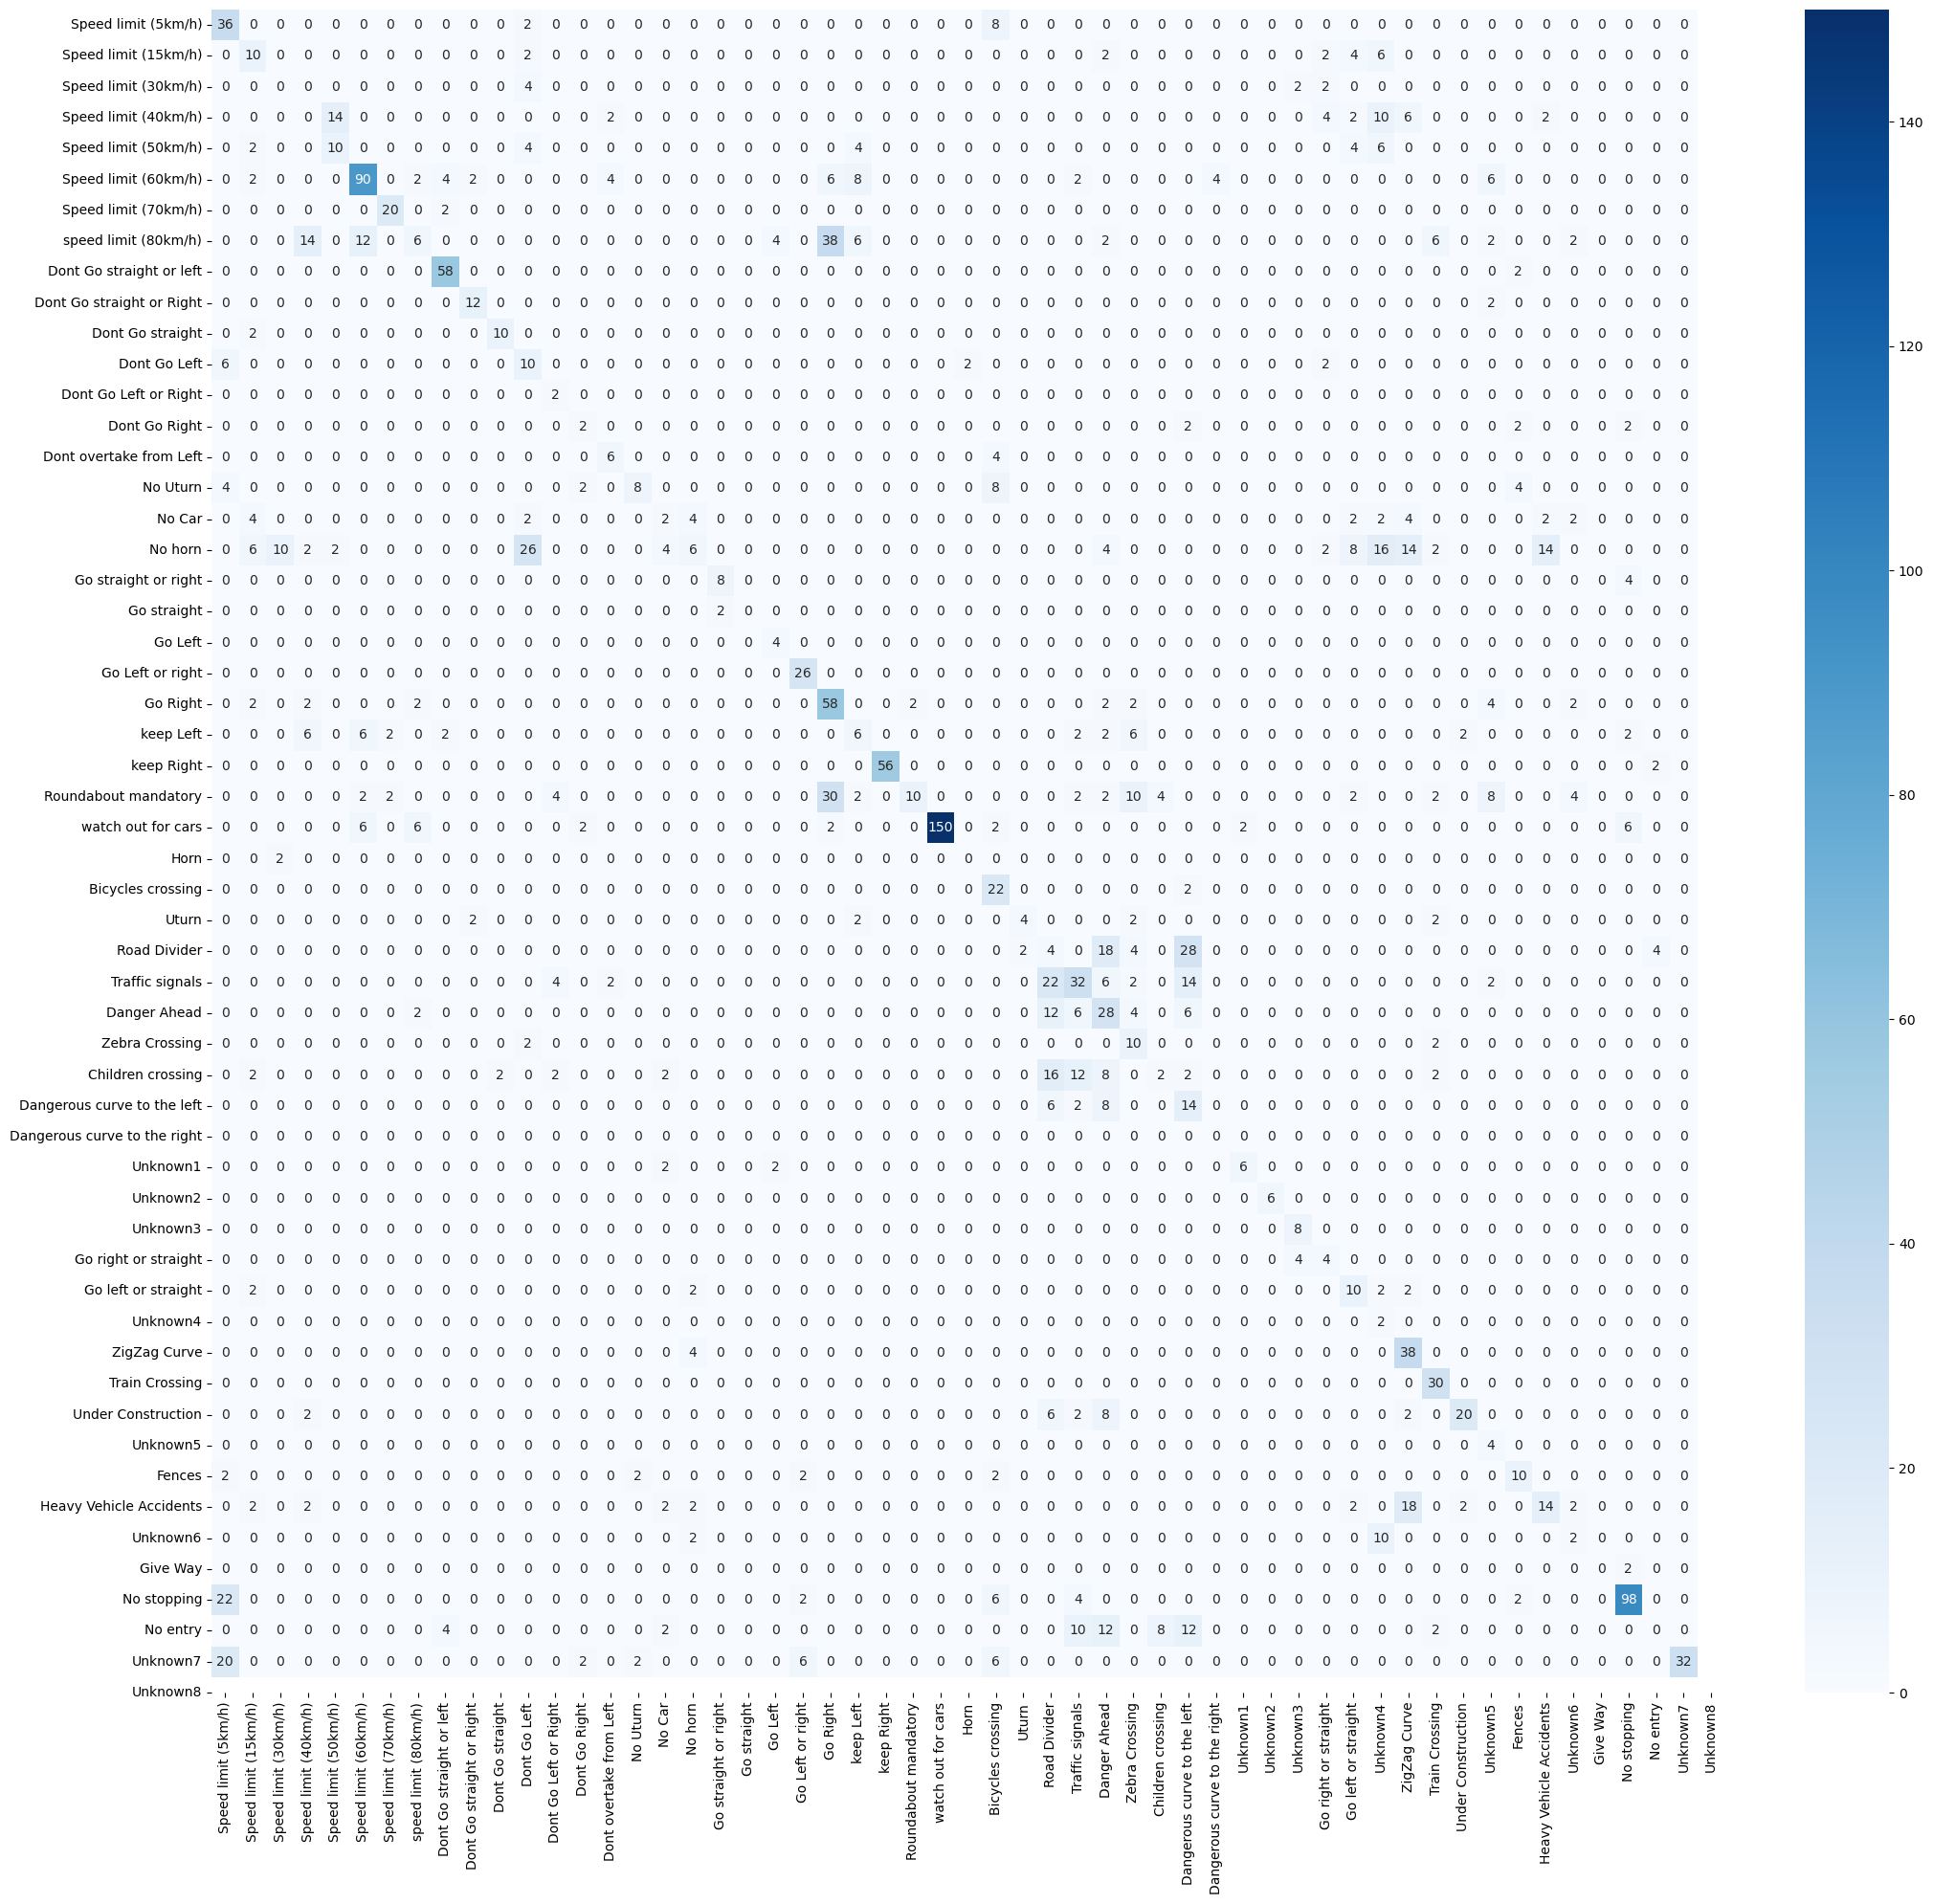

In [50]:
plt.figure(figsize=(22, 20))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=label_to_num.keys(),
    yticklabels=label_to_num.keys(),
)
plt.tight_layout()